<a href="https://colab.research.google.com/github/ssebastian0626/DSEM-assignment-4-/blob/Current-status-05.07.2026/4_existing_plant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import requests

folder_url = "https://tubcloud.tu-berlin.de/s/567ckizz2Y6RLQq/download?path=%2Fglobal-power-plant-database&files=global_power_plant_database.csv"

r = requests.get(folder_url)
r.raise_for_status()

with open("global_power_plant_database.csv", "wb") as f:
    f.write(r.content)

In [7]:
import pandas as pd

powerplants = pd.read_csv("global_power_plant_database.csv")

powerplants.head()

/tmp/ipykernel_2175/734875097.py:3: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  powerplants = pd.read_csv("global_power_plant_database.csv")


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.1190,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.7950,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.7920,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.556,69.4787,Hydro,NaN,NaN,...,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.641,69.7170,Hydro,NaN,NaN,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1


In [8]:
powerplants.columns.tolist()

['country',
 'country_long',
 'name',
 'gppd_idnr',
 'capacity_mw',
 'latitude',
 'longitude',
 'primary_fuel',
 'other_fuel1',
 'other_fuel2',
 'other_fuel3',
 'commissioning_year',
 'owner',
 'source',
 'url',
 'geolocation_source',
 'wepp_id',
 'year_of_capacity_data',
 'generation_gwh_2013',
 'generation_gwh_2014',
 'generation_gwh_2015',
 'generation_gwh_2016',
 'generation_gwh_2017',
 'generation_gwh_2018',
 'generation_gwh_2019',
 'generation_data_source',
 'estimated_generation_gwh_2013',
 'estimated_generation_gwh_2014',
 'estimated_generation_gwh_2015',
 'estimated_generation_gwh_2016',
 'estimated_generation_gwh_2017',
 'estimated_generation_note_2013',
 'estimated_generation_note_2014',
 'estimated_generation_note_2015',
 'estimated_generation_note_2016',
 'estimated_generation_note_2017']

In [9]:
powerplants["primary_fuel"].value_counts()

,count
primary_fuel,
Solar,10665
Hydro,7156
Wind,5344
Gas,3998
Coal,2330
Oil,2320
Biomass,1430
Waste,1068
Nuclear,195


In [10]:
powerplants_at = powerplants[powerplants["country"] == "AUT"].copy()

len(powerplants_at)

103

In [11]:
powerplants_at["primary_fuel"].value_counts()

,count
primary_fuel,
Hydro,96
Wind,4
Gas,3


In [12]:
powerplants_at = powerplants_at[
    powerplants_at["primary_fuel"] != "Wind"
].copy()

In [13]:
import geopandas as gpd
import requests

url_gadm = (
    "https://tubcloud.tu-berlin.de/s/567ckizz2Y6RLQq/"
    "download?path=%2Fgadm&files=gadm_410-levels-ADM_1-AUT.gpkg"
)

r = requests.get(url_gadm)
r.raise_for_status()

with open("gadm_410-levels-ADM_1-AUT.gpkg", "wb") as f:
    f.write(r.content)

regions = gpd.read_file("gadm_410-levels-ADM_1-AUT.gpkg")

In [14]:
regions.columns

Index(['GID_0', 'GID_1', 'COUNTRY', 'NAME_1', 'geometry'], dtype='object')

<Axes: >

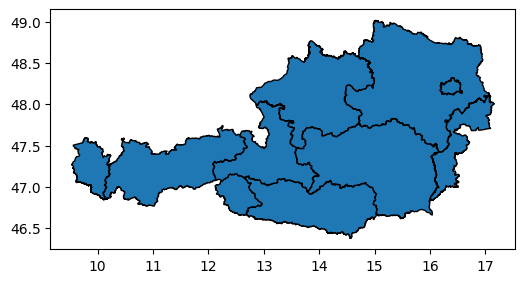

In [15]:
regions.plot(figsize=(6, 8), edgecolor="black")

In [16]:
from shapely.geometry import Point

powerplants_gdf = gpd.GeoDataFrame(
    powerplants_at,
    geometry=gpd.points_from_xy(
        powerplants_at.longitude,
        powerplants_at.latitude
    ),
    crs="EPSG:4326"
)

regions = regions.to_crs(powerplants_gdf.crs)

In [17]:
plants_region = gpd.sjoin(
    powerplants_gdf,
    regions[["NAME_1", "geometry"]],
    how="left",
    predicate="within"
)

In [18]:
plants_region[["name", "primary_fuel", "capacity_mw", "NAME_1"]].head()

,name,primary_fuel,capacity_mw,NAME_1
822,Abwinden-Asten,Hydro,168.0,Oberösterreich
823,Altenmarkt,Hydro,26.0,Steiermark
824,Arnstein,Hydro,30.0,Steiermark
825,Aschach,Hydro,287.0,Oberösterreich
826,Bischofshofen,Hydro,16.0,Salzburg


In [19]:
plants_region["NAME_1"].value_counts()

,count
NAME_1,
Steiermark,26
Oberösterreich,16
Salzburg,14
Kärnten,13
Tirol,11
Vorarlberg,7
Wien,5
Niederösterreich,3


In [20]:
existing_generators = (
    plants_region
    .groupby(["NAME_1", "primary_fuel"], as_index=False)["capacity_mw"]
    .sum()
    .sort_values(["NAME_1", "primary_fuel"])
)

existing_generators

,NAME_1,primary_fuel,capacity_mw
0,Kärnten,Hydro,1332.0
1,Niederösterreich,Hydro,716.0
2,Oberösterreich,Gas,400.0
3,Oberösterreich,Hydro,1313.0
4,Salzburg,Hydro,1076.0
5,Steiermark,Hydro,410.0
6,Tirol,Hydro,1992.0
7,Vorarlberg,Hydro,1571.0
8,Wien,Gas,1667.0
9,Wien,Hydro,358.0


In [21]:
existing_generators.groupby("primary_fuel")["capacity_mw"].sum()

,capacity_mw
primary_fuel,
Gas,2067.0
Hydro,8768.0


In [22]:
existing_generators.to_csv("existing_generators.csv", index=False)

In [23]:
import requests
import pandas as pd

url_load = (
    "https://tubcloud.tu-berlin.de/s/567ckizz2Y6RLQq/"
    "download?path=%2Fgegis&files=load.csv"
)

r = requests.get(url_load)
r.raise_for_status()

with open("load.csv", "wb") as f:
    f.write(r.content)

load = pd.read_csv("load.csv")

In [24]:
load.head()

,time,AE,AL,AM,AO,AR,AT,AU,AZ,BA,...,US,UY,UZ,VE,VN,YE,ZA,ZM,ZW,Unnamed: 139
0,2013-01-01 00:00:00,16140.623495,757.486559,667.467203,1214.299589,25204.670505,9072.979417,33425.016188,2182.839695,1409.106216,...,680747.233701,1942.051338,7002.022644,16515.980591,19899.245127,658.115848,33663.735869,1673.595871,1149.582332,581.577290
1,2013-01-01 01:00:00,17423.984557,732.913217,712.527478,1240.189854,24914.320557,9069.513180,33784.051684,2301.666892,1390.834176,...,674603.328281,1912.187569,7377.288011,16531.455318,21743.976520,665.618837,33373.498375,1684.431454,1155.804120,573.140990
2,2013-01-01 02:00:00,17975.465644,730.126405,818.316334,1231.127006,24265.144747,9089.894101,33810.656741,2602.477909,1383.550755,...,647518.041077,1746.457356,7826.869007,17233.480858,23298.439401,718.949145,33373.498375,1704.162179,1160.072704,569.218815
3,2013-01-01 03:00:00,19621.847025,731.702857,870.521907,1246.256959,22331.379630,9147.112904,34365.541198,2915.682062,1387.453092,...,616426.802491,1629.417557,8065.243716,16582.591063,24021.200175,761.965169,34373.484789,1905.046529,1298.766289,612.869228
4,2013-01-01 04:00:00,21415.787184,743.389539,862.778359,1406.850126,21001.189997,9683.371098,34365.541198,3150.220677,1485.746498,...,573767.576287,1539.296604,8210.738149,16525.386146,24032.065871,813.332767,35875.479510,1972.523216,1331.850162,613.947401


In [25]:
load.columns

Index(['time', 'AE', 'AL', 'AM', 'AO', 'AR', 'AT', 'AU', 'AZ', 'BA',
       ...
       'US', 'UY', 'UZ', 'VE', 'VN', 'YE', 'ZA', 'ZM', 'ZW', 'Unnamed: 139'],
      dtype='object', length=140)

In [26]:
load.shape

(8760, 140)

In [27]:
load_at = load[["time", "AT"]].copy()

load_at["time"] = pd.to_datetime(load_at["time"])

load_at = load_at.set_index("time")

load_at.head()

,AT
time,
2013-01-01 00:00:00,9072.979417
2013-01-01 01:00:00,9069.513180
2013-01-01 02:00:00,9089.894101
2013-01-01 03:00:00,9147.112904
2013-01-01 04:00:00,9683.371098


In [28]:
population = pd.DataFrame({
    "NAME_1": [
        "Burgenland",
        "Kärnten",
        "Niederösterreich",
        "Oberösterreich",
        "Salzburg",
        "Steiermark",
        "Tirol",
        "Vorarlberg",
        "Wien"
    ],
    "population": [
        297583,
        564513,
        1698796,
        1505140,
        560710,
        1252922,
        764102,
        401647,
        1931593
    ]
})

In [29]:
population["share"] = population["population"] / population["population"].sum()

population

,NAME_1,population,share
0,Burgenland,297583,0.033149
1,Kärnten,564513,0.062884
2,Niederösterreich,1698796,0.189239
3,Oberösterreich,1505140,0.167666
4,Salzburg,560710,0.062461
5,Steiermark,1252922,0.139570
6,Tirol,764102,0.085118
7,Vorarlberg,401647,0.044742
8,Wien,1931593,0.215171


In [30]:
regional_load = load_at.copy()

for _, row in population.iterrows():
    regional_load[row["NAME_1"]] = load_at["AT"] * row["share"]

regional_load = regional_load.drop(columns="AT")

regional_load.head()

,Burgenland,Kärnten,Niederösterreich,Oberösterreich,Salzburg,Steiermark,Tirol,Vorarlberg,Wien
time,,,,,,,,,
2013-01-01 00:00:00,300.764468,570.548224,1716.957874,1521.231493,566.704566,1266.317023,772.271035,405.941019,1952.243714
2013-01-01 01:00:00,300.649564,570.330252,1716.301929,1520.650322,566.488062,1265.833240,771.975997,405.785934,1951.497879
2013-01-01 02:00:00,301.325181,571.611893,1720.158786,1524.067513,567.761069,1268.677808,773.710774,406.697812,1955.883266
2013-01-01 03:00:00,303.221954,575.210059,1730.986791,1533.661169,571.334995,1276.663845,778.581106,409.257881,1968.195104
2013-01-01 04:00:00,320.998629,608.932295,1832.467538,1623.573514,604.830052,1351.509477,824.226164,433.251014,2083.582414


In [31]:
(regional_load.sum(axis=1) - load_at["AT"]).abs().max()

1.8189894035458565e-12

In [33]:
regional_load.to_csv("regional_load.csv")

In [34]:
import pandas as pd

url = "https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_2030.csv"

costs = pd.read_csv(url, index_col=[0, 1])

costs.head()

value           unit  \
technology                       parameter                                    
Alkaline electrolyzer large size FOM                  2.8000         %/year   
                                 VOM                  0.3033     EUR/MWh_H2   
                                 electricity-input    1.3800  MWh_el/MWh_H2   
                                 investment         544.7764         EUR/kW   
                                 lifetime            40.0000          years   

                                                                                               source  \
technology                       parameter                                                              
Alkaline electrolyzer large size FOM                JRC, 01_JRC-EU-TIMES Full model, https://zenod...   
                                 VOM                JRC, 01_JRC-EU-TIMES Full model, https://zenod...   
                                 electricity-input  JRC, 01_JRC-EU-TIMES Full model, https://zenod...   
                                 investment         JRC, 01_JRC-EU-TIMES Full model, https://zenod...   
                                 lifetime           JRC, 01_JRC-EU-TIMES Full model, https://zenod...   

                                                         further description  \
technology                       parameter                                     
Alkaline electrolyzer large size FOM                Reference capacity 72 MW   
                                 VOM                Reference capacity 72 MW   
                                 electricity-input  Reference capacity 72 MW   
                                 investment         Reference capacity 72 MW   
                                 lifetime           Reference capacity 72 MW   

                                                    currency_year  
technology                       parameter                         
Alkaline electrolyzer large size FOM                       2010.0  
                                 VOM                       2025.0  
                                 electricity-input            NaN  
                                 investment                2025.0  
                                 lifetime                     NaN

In [35]:
costs.index.get_level_values(0).unique()

Index(['Alkaline electrolyzer large size', 'Alkaline electrolyzer medium size',
       'Alkaline electrolyzer small size', 'Ammonia cracker', 'BEV Bus city',
       'BEV Coach', 'BEV Truck Semi-Trailer max 50 tons',
       'BEV Truck Solo max 26 tons', 'BEV Truck Trailer max 56 tons',
       'Battery electric (passenger cars)',
       ...
       'solid biomass', 'solid biomass boiler steam',
       'solid biomass boiler steam CC', 'solid biomass to hydrogen',
       'steel carbon capture retrofit', 'uranium', 'waste CHP', 'waste CHP CC',
       'water tank charger', 'water tank discharger'],
      dtype='object', name='technology', length=300)

In [36]:
techs = [
    "hydro",
    "onwind",
    "solar",
    "CCGT",
    "OCGT"
]

costs_at = costs.loc[costs.index.get_level_values(0).isin(techs)]

costs_at.head(20)

value        unit  \
technology parameter                           
CCGT       FOM            3.3494      %/year   
           VOM            5.6104     EUR/MWh   
           c_b            2.0000  50oC/100oC   
           c_v            0.1500  50oC/100oC   
           efficiency     0.5800    per unit   
           investment  1108.7166      EUR/kW   
           lifetime      25.0000       years   
OCGT       FOM            1.7795      %/year   
           VOM            6.0111     EUR/MWh   
           efficiency     0.4100    per unit   
           investment   581.3949      EUR/kW   
           lifetime      25.0000       years   
hydro      FOM            1.0000      %/year   
           efficiency     0.9000    per unit   
           investment  2888.5279    EUR/kWel   
           lifetime      80.0000       years   
onwind     FOM            1.2167      %/year   
           VOM            1.8033     EUR/MWh   
           investment  1383.3059      EUR/kW   
           lifetime      30.0000       years   

                                                                  source  \
technology parameter                                                       
CCGT       FOM         Danish Energy Agency, inputs/technology_data_f...   
           VOM         Danish Energy Agency, inputs/technology_data_f...   
           c_b         Danish Energy Agency, inputs/technology_data_f...   
           c_v         Danish Energy Agency, inputs/technology_data_f...   
           efficiency  Danish Energy Agency, inputs/technology_data_f...   
           investment  Danish Energy Agency, inputs/technology_data_f...   
           lifetime    Danish Energy Agency, inputs/technology_data_f...   
OCGT       FOM         Danish Energy Agency, inputs/technology_data_f...   
           VOM         Danish Energy Agency, inputs/technology_data_f...   
           efficiency  Danish Energy Agency, inputs/technology_data_f...   
           investment  Danish Energy Agency, inputs/technology_data_f...   
           lifetime    Danish Energy Agency, inputs/technology_data_f...   
hydro      FOM             DIW DataDoc http://hdl.handle.net/10419/80348   
           efficiency      DIW DataDoc http://hdl.handle.net/10419/80348   
           investment      DIW DataDoc http://hdl.handle.net/10419/80348   
           lifetime                                              IEA2010   
onwind     FOM         Danish Energy Agency, inputs/technology_data_f...   
           VOM         Danish Energy Agency, inputs/technology_data_f...   
           investment  Danish Energy Agency, inputs/technology_data_f...   
           lifetime    Danish Energy Agency, inputs/technology_data_f...   

                                                     further description  \
technology parameter                                                       
CCGT       FOM               05 Gas turb. CC, steam extract.:  Fixed O&M   
           VOM            05 Gas turb. CC, steam extract.:  Variable O&M   
           c_b          05 Gas turb. CC, steam extract.:  Cb coefficient   
           c_v          05 Gas turb. CC, steam extract.:  Cv coefficient   
           efficiency  05 Gas turb. CC, steam extract.:  Electricity ...   
           investment  05 Gas turb. CC, steam extract.:  Nominal inve...   
           lifetime    05 Gas turb. CC, steam extract.:  Technical li...   
OCGT       FOM                         52 OCGT - Natural gas:  Fixed O&M   
           VOM                      52 OCGT - Natural gas:  Variable O&M   
           efficiency  52 OCGT - Natural gas:  Electricity efficiency...   
           investment        52 OCGT - Natural gas:  Specific investment   
           lifetime           52 OCGT - Natural gas:  Technical lifetime   
hydro      FOM                           from old pypsa cost assumptions   
           efficiency                    from old pypsa cost assumptions   
           investment                    from old pypsa cost assumptions   
     

In [37]:
costs_table = (
    costs_at["value"]
    .unstack(level=1)
)

costs_table

parameter,FOM,VOM,c_b,c_v,efficiency,investment,lifetime
technology,,,,,,,
CCGT,3.3494,5.6104,2.0,0.15,0.58,1108.7166,25.0
OCGT,1.7795,6.0111,NaN,NaN,0.41,581.3949,25.0
hydro,1.0000,NaN,NaN,NaN,0.90,2888.5279,80.0
onwind,1.2167,1.8033,NaN,NaN,NaN,1383.3059,30.0
solar,1.9495,0.0134,NaN,NaN,NaN,683.1462,40.0


In [38]:
costs_table.to_csv("technology_costs.csv")